# How to use the FCI algorithm on data with discrete variables

## Import and settings

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

import warnings
warnings.filterwarnings('ignore')

# version
import sklearn
import matplotlib
import platform
print('python', platform.python_version())
for lib in [np, pd, sklearn, matplotlib, nx]:
    print(lib.__name__, lib.__version__)

np.set_printoptions(precision=3, suppress=True)

python 3.11.9
numpy 2.3.2
pandas 2.3.2
sklearn 1.7.1
matplotlib 3.10.5
networkx 3.5


## Test data
First, we generate a causal structure with 8 variables.

These variables are grouped as follows:
- Exogenous variables: X1, B1, T1
- Endogenous variables: X2_1, X2_2, X2_3, X2_4
- Sink variable: B3

The types of the variables are as follows:
- Continuous variables: X1, X2_1, X2_2, X2_3, X2_4
- Binary variables: B1, B3
- Ternary variable: T1

In addition, there are 2 latent variables, U1 and U2.

In [2]:
rng = np.random.default_rng(0)

n_sample = 1000
sigmoid = lambda z: 1/(1 + np.exp(-z))

U1 = rng.normal(0, 1, n_sample)
U2 = rng.normal(0, 1, n_sample)

X1 = 0.9 * U1 + rng.normal(0, 1, n_sample) # X1 <- U1
B1 = rng.binomial(1, sigmoid(0.8 * U1), size=n_sample) # B1 <- U1

Zt = 1.0 * rng.normal(0, 1, n_sample)
q1, q2 = np.quantile(Zt, [1/3, 2/3])
T1 = np.digitize(Zt, bins=[q1, q2])

X2_1 = 0.9 * X1 - 0.8 * B1 - 0.4 * U2 + rng.normal(0, 1, n_sample) # X2_1 <- X1, B1, U2
X2_2 = 0.4 * B1 - 0.3 * T1 + rng.normal(0, 1, n_sample) # X2_2 <- B1, T1
X2_3 = 0.5 * T1 + 0.5 * U2 + rng.normal(0, 1, n_sample) # X2_3 <- T1, U2
X2_4 = 0.3 * X1 + 0.6 * X2_1 + 0.7 * X2_3 + rng.normal(0, 1, n_sample) # X2_4 <- X1, X2_1, X2_3

B3 = rng.binomial(1, sigmoid(0.9 * X2_3 + 1.1 * X2_4), size=n_sample) # B3 <- X2_3, X2_4

X = pd.DataFrame({'X1': X1, 'B1': B1, 'T1': T1, 'X2_1': X2_1, 'X2_2': X2_2, 'X2_3': X2_3, 'X2_4': X2_4, 'B3': B3})
NODE_NAMES = list(X.columns)
X.head()

,X1,B1,T1,X2_1,X2_2,X2_3,X2_4,B3
0,0.532412,0,2,0.864091,-1.051817,3.101597,0.473708,1
1,-0.621139,0,2,1.314322,-1.085594,-1.128762,-0.918794,1
2,-0.281320,1,0,-1.493406,0.084458,-0.585393,-0.136750,1
3,-1.505895,0,2,-2.383614,-0.503731,0.713074,-2.638350,0
4,-2.162436,0,2,0.419559,0.349438,-0.382863,1.598834,1


Histograms of test data are as follows:

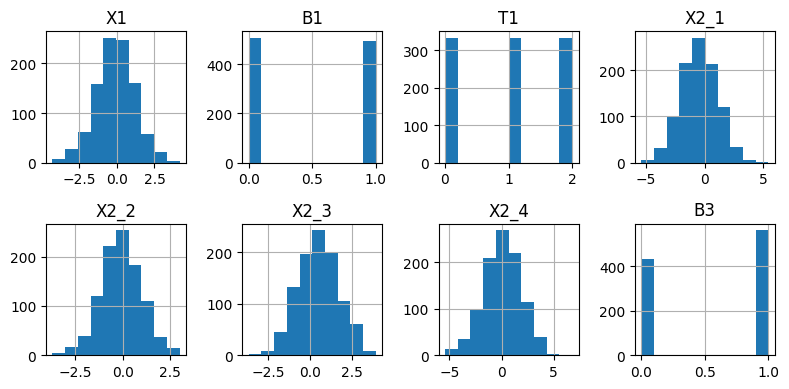

In [3]:
X.hist(layout=(2, 4), figsize=(8, 4))
plt.tight_layout()
plt.show()

### Classify test data variables into three subsets
We classify test data variables into three subsets: exogenous variables, endogenous variables, and the sink variable.

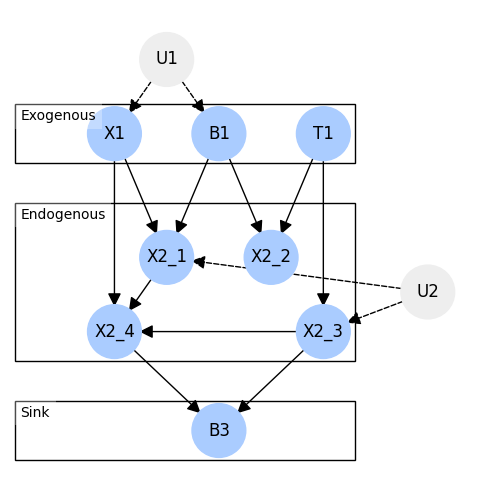

In [4]:
def add_fixed_box(ax, box, label, *, padding=0.01):
    x0, y0, w, h = box
    rect = patches.Rectangle((x0, y0), w, h, fill=False)
    ax.add_patch(rect)
    ax.text(
        x0 + padding, y0 + h - padding, label,
        ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
    )
    return rect

# Node positions
POS = {
    'U1': (0.3, 0.95),
    'X1': (0.2, 0.8),
    'B1': (0.4, 0.8),
    'T1': (0.6, 0.8),
    'U2': (0.8, 0.48),
    'X2_1': (0.3, 0.55),
    'X2_2': (0.5, 0.55),
    'X2_3': (0.6, 0.4),
    'X2_4': (0.2, 0.4),
    'B3': (0.4, 0.2),
}

B_true = pd.DataFrame([
    [0,  0,  0,  1,  0,  0,  1,  0],
    [0,  0,  0,  1,  1,  0,  0,  0],
    [0,  0,  0,  0,  1,  1,  0,  0],
    [0,  0,  0,  0,  0,  0,  1,  0],
    [0,  0,  0,  0,  0,  0,  0,  0],
    [0,  0,  0,  0,  0,  0,  1,  1],
    [0,  0,  0,  0,  0,  0,  0,  1],
    [0,  0,  0,  0,  0,  0,  0,  0]
], index=NODE_NAMES, columns=NODE_NAMES)

G_true = nx.from_pandas_adjacency(B_true, create_using=nx.DiGraph)

# Latent Confounder
latent_nodes = {'U1', 'U2'}
latent_edges = [
    ('U1', 'X1'),
    ('U1', 'B1'),
    ('U2', 'X2_1'),
    ('U2', 'X2_3'),
]
G_true.add_nodes_from(['U1', 'U2'])
G_true.add_edges_from(latent_edges)
node_colors = ['#EEEEEE' if n in latent_nodes else '#AACCFF' for n in G_true.nodes()]

# Draw nodes
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_nodes(
    G_true, POS,
    node_color=node_colors,
    node_size=1500,
    ax=ax
)
nx.draw_networkx_labels(G_true, POS, ax=ax)

# Draw edges
dashed_edges = [(u, v) for (u, v) in G_true.edges() if (u in latent_nodes or v in latent_nodes)]
solid_edges  = [(u, v) for (u, v) in G_true.edges() if (u, v) not in dashed_edges]

nx.draw_networkx_edges(
    G_true, POS,
    edgelist=solid_edges,
    arrowsize=20,
    min_target_margin=18,
    ax=ax
)
nx.draw_networkx_edges(
    G_true, POS,
    edgelist=dashed_edges,
    arrowsize=20,
    min_target_margin=18,
    style='dashed'
)

xs, ys = map(np.array, zip(*POS.values()))
ax.set_xlim(xs.min() - 0.20, xs.max() + 0.10)
ax.set_ylim(ys.min() - 0.10, ys.max() + 0.10)

# Draw grouping boxes
add_fixed_box(ax, (0.01, 0.74, 0.65, 0.12), 'Exogenous')
add_fixed_box(ax, (0.01, 0.34, 0.65, 0.32), 'Endogenous')
add_fixed_box(ax, (0.01, 0.14, 0.65, 0.12), 'Sink')

ax.set_axis_off()
plt.tight_layout()
plt.show()

## Setting prior knowledge
Based on a three-layer structure of exogenous, endogenous, and sink variables, reverse-direction edges are prohibited.

In [5]:
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

exog_var_names = ['X1', 'B1', 'T1']
endog_var_names = ['X2_1', 'X2_2', 'X2_3', 'X2_4']
sink_var_name = 'B3'

all_names = exog_var_names + endog_var_names + [sink_var_name]
nodes = {name: GraphNode(name) for name in all_names}

# Setting prior knowledge
bk = BackgroundKnowledge()

# Prohibit edges Endogenous -> Exogenous
for endog in endog_var_names:
    for exog in exog_var_names:
        bk.add_forbidden_by_node(nodes[endog], nodes[exog])

# Prohibit edges Exogenous <-> Sink
for exog in exog_var_names:
    bk.add_forbidden_by_node(nodes[sink_var_name], nodes[exog])
    bk.add_forbidden_by_node(nodes[endog], nodes[sink_var_name])

# Prohibit edges Sink -> Endogenous
for endog in endog_var_names:
    bk.add_forbidden_by_node(nodes[sink_var_name], nodes[endog])

## FCI algorithm

In [6]:
%%time
from io import StringIO
from causallearn.search.ConstraintBased.FCI import fci

# start capture
default_out = sys.stdout
sys.stdout = StringIO()

G_fci, _ = fci(
    X.values,
    node_names=NODE_NAMES,
    is_discrete=[False, True, True, False, False, False, False, True],
    indep_test='kci', # Use KCI for the independence test
    background_knowledge=bk,
    show_progress=False, 
    verbose=False
)

# stop capture
del sys.stdout
sys.stdout = default_out

adjacency_matrix = G_fci.graph
B_est = pd.DataFrame(adjacency_matrix, index=NODE_NAMES, columns=NODE_NAMES)
B_est

CPU times: total: 78.1 ms
Wall time: 222 ms


,X1,B1,T1,X2_1,X2_2,X2_3,X2_4,B3
X1,0,2,0,-1,0,0,-1,0
B1,2,0,0,-1,-1,0,0,0
T1,0,0,0,0,-1,-1,0,0
X2_1,1,1,0,0,0,1,1,0
X2_2,0,1,1,0,0,0,0,0
X2_3,0,0,1,1,0,0,-1,-1
X2_4,1,0,0,1,0,1,0,0
B3,0,0,0,0,0,1,0,0


## Visualize a result
The causal graph is as follows:

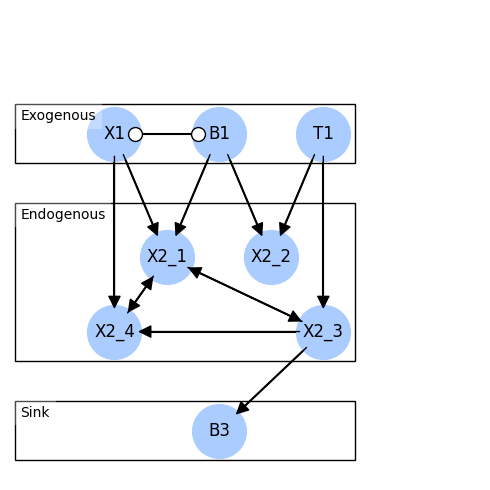

In [7]:
from matplotlib.patches import FancyArrowPatch

# causal-learn endpoint codes
TAIL, ARROW, CIRCLE, NULL = -1, 1, 2, 0

n_variables = len(NODE_NAMES)

# undirected skeleton graph for positioning
G_est = nx.Graph()
G_est.add_nodes_from(NODE_NAMES)

# collect unique edges (i < j) where something exists
edges = []
for i in range(n_variables):
    for j in range(i + 1, n_variables):
        if adjacency_matrix[i, j] != NULL or adjacency_matrix[j, i] != NULL:
            G_est.add_edge(NODE_NAMES[i], NODE_NAMES[j])
            edges.append((i, j))

fig, ax = plt.subplots(figsize=(5, 5))

# draw nodes
nx.draw_networkx_nodes(G_est, POS, node_color='#AACCFF', node_size=1500, ax=ax)
nx.draw_networkx_labels(G_est, POS, ax=ax)

for i, j in edges:
    p_i = POS[NODE_NAMES[i]]
    p_j = POS[NODE_NAMES[j]]

    # base line
    ax.plot([p_i[0], p_j[0]], [p_i[1], p_j[1]], color='black', zorder=1)

    # direction vector (for small offsets)
    vx = p_j[0] - p_i[0]
    vy = p_j[1] - p_i[1]
    norm = (vx**2 + vy**2) ** 0.5 + 1e-12
    ux, uy = vx / norm, vy / norm

    # endpoint types at i and j
    a_ij = adjacency_matrix[i, j]
    a_ji = adjacency_matrix[j, i]

    # draw arrowheads
    # j -> i
    if a_ij == ARROW:
        p_start = (p_j[0] - ux * 0.04, p_j[1] - uy * 0.04)
        p_end = (p_i[0] + ux * 0.04, p_i[1] + uy * 0.04)
        arrow = FancyArrowPatch(p_start, p_end, arrowstyle='-|>', mutation_scale=20, color="black", zorder=2)
        ax.add_patch(arrow)

    # i -> j
    if a_ji == ARROW:
        p_start = (p_i[0] + ux * 0.04, p_i[1] + uy * 0.04)
        p_end = (p_j[0] - ux * 0.04, p_j[1] - uy * 0.04)
        arrow = FancyArrowPatch(p_start, p_end, arrowstyle='-|>', mutation_scale=20, color="black", zorder=2)
        ax.add_patch(arrow)

    # draw circle endpoints
    if a_ij == CIRCLE:
        x = p_i[0] + ux * 0.04
        y = p_i[1] + uy * 0.04
        ax.scatter([x], [y], s=100, facecolors='white', edgecolors='black', zorder=3)

    if a_ji == CIRCLE:
        x = p_j[0] - ux * 0.04
        y = p_j[1] - uy * 0.04
        ax.scatter([x], [y], s=100, facecolors='white', edgecolors='black', zorder=3)

xs = np.array([p[0] for p in POS.values()])
ys = np.array([p[1] for p in POS.values()])
ax.set_xlim(xs.min() - 0.20, xs.max() + 0.10)
ax.set_ylim(ys.min() - 0.10, ys.max() + 0.10)

# Draw a box
add_fixed_box(ax, (0.01, 0.74, 0.65, 0.12), 'Exogenous')
add_fixed_box(ax, (0.01, 0.34, 0.65, 0.32), 'Endogenous')
add_fixed_box(ax, (0.01, 0.14, 0.65, 0.12), 'Sink')

ax.set_axis_off()
plt.tight_layout()
plt.show()

## Perform bootstrapping

In [8]:
from sklearn.utils import resample

def bootstrap(X, n_sampling=100):
    rng = np.random.default_rng(0)
    results = []
    for i in range(n_sampling):
        seed_i = int(rng.integers(2**32))
        resampled_X = resample(X, random_state=seed_i)
        G_fci, _ = fci(
            resampled_X.values,
            node_names=NODE_NAMES,
            is_discrete=[False, True, True, False, False, False, False, True],
            indep_test='kci', # Use KCI for the independence test
            background_knowledge=bk,
            show_progress=False, 
            verbose=False
        )
        results.append(G_fci) # Save the results

    return results

In [9]:
%%time
# start capture
default_out = sys.stdout
sys.stdout = StringIO()

results = bootstrap(X, n_sampling=100)

# stop capture
del sys.stdout
sys.stdout = default_out

CPU times: total: 1.3 s
Wall time: 1.69 s


## Compute precision, recall, and F1

In [10]:
from causallearn.graph.GeneralGraph import GeneralGraph

# Convert the true causal graph to a GeneralGraph
A = np.asarray(B_true.values)
nodes = [GraphNode(name) for name in NODE_NAMES]
G_true_graph = GeneralGraph(nodes)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if i != j and A[i, j] == 1:
            G_true_graph.add_directed_edge(nodes[i], nodes[j])  # i -> j

In [11]:
from causallearn.graph.AdjacencyConfusion import AdjacencyConfusion
from causallearn.graph.ArrowConfusion import ArrowConfusion

rows = []
for G_est_graph in results:
    # Compute with edge skeleton
    adjacency_confusion = AdjacencyConfusion(G_true_graph, G_est_graph)
    precision_skeleton = adjacency_confusion.get_adj_precision()
    recall_skeleton = adjacency_confusion.get_adj_recall()
    f1_skeleton = 0.0 if (precision_skeleton + recall_skeleton) == 0 else 2 * precision_skeleton * recall_skeleton / (precision_skeleton + recall_skeleton)
    # Compute with edge directions
    arrow_confusion = ArrowConfusion(G_true_graph, G_est_graph)
    precision_directed = arrow_confusion.get_arrows_precision()
    recall_directed  = arrow_confusion.get_arrows_recall()
    f1_directed = 0.0 if (precision_directed + recall_directed) == 0 else 2 * precision_directed * recall_directed / (precision_directed + recall_directed)
    # Save the results
    rows.append({
        "precision_skeleton": precision_skeleton, "recall_skeleton": recall_skeleton, "f1_skeleton": f1_skeleton,
        "precision_directed": precision_directed, "recall_directed": recall_directed, "f1_directed": f1_directed
    })

df_results = pd.DataFrame(rows)
df_results.head()

,precision_skeleton,recall_skeleton,f1_skeleton,precision_directed,recall_directed,f1_directed
0,0.818182,0.9,0.857143,0.75,0.9,0.818182
1,0.818182,0.9,0.857143,0.75,0.9,0.818182
2,0.818182,0.9,0.857143,0.75,0.9,0.818182
3,0.818182,0.9,0.857143,0.75,0.9,0.818182
4,0.818182,0.9,0.857143,0.75,0.9,0.818182


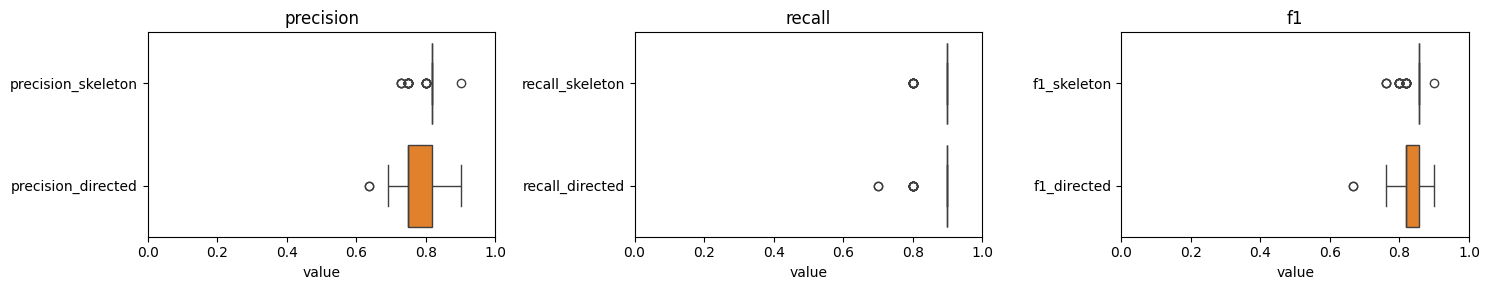

In [12]:
pairs = {
    'precision': ['precision_skeleton', 'precision_directed'],
    'recall':    ['recall_skeleton', 'recall_directed'],
    'f1':        ['f1_skeleton', 'f1_directed'],
}

# Show box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharex=True)
for ax, (metric, cols) in zip(axes, pairs.items()):
    sns.boxplot(data=df_results[cols], orient='h', ax=ax)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.set_xlabel('value')
plt.tight_layout()
plt.show()

## Directed edge counts (excluding bidirectional edges)

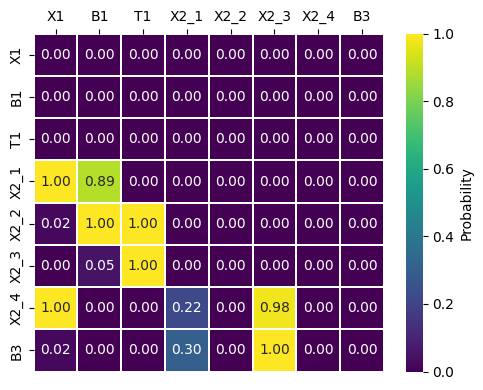

In [13]:
n = len(NODE_NAMES)
counts = np.zeros((n, n), dtype=float)
for G_est_graph in results:
    A = G_est_graph.graph
    edge_ij = ((A == 1) & (A.T == -1)).astype(float)
    counts += edge_ij

prob = counts / len(results)
prob_df = pd.DataFrame(prob, index=NODE_NAMES, columns=NODE_NAMES)

plt.figure(figsize=(5, 4))
ax = sns.heatmap(prob_df, cmap='viridis', linewidths=0.3, linecolor='white', fmt='.2f', annot=True, cbar_kws={'label': 'Probability'})
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.show()